In [59]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import math
import random
from infomap import Infomap

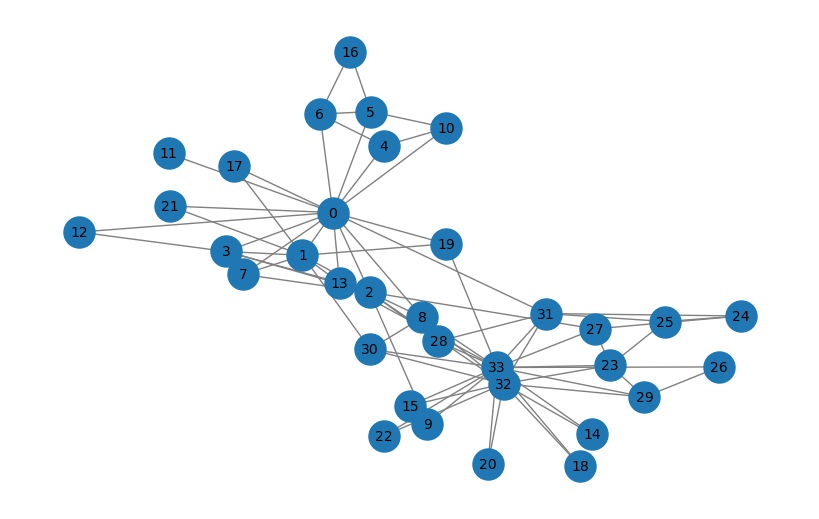

In [5]:
# A reference network
G = nx.karate_club_graph()

pos = nx.spring_layout(G, seed=42)
plt.figure(figsize=(8, 5))
nx.draw(G, pos, with_labels=True, node_size=500, edge_color="gray", font_size=10, font_color="black")
plt.show()

Given a partition $M$, the final formula for the map equation $L(M)$ reads:

$$
L(M) = \left(\sum_i^m q_{i\curvearrowright}\right) \log\left(\sum_i^m q_{i\curvearrowright}\right)  - 2 \sum_i^m q_{i\curvearrowright} \log(q_{i\curvearrowright}) + \sum_i^m \left(q_{i\curvearrowright} + \sum_{\alpha \in i} p_\alpha\right) \log\left(q_{i\curvearrowright} + \sum_{\alpha \in i} p_\alpha\right) + H[p_\alpha]
$$
where $q_{i\curvearrowright}$ is the probability that in a generic timestep the random walker will leave the module $i$ and $p_\alpha$ is the equilibrium distribution value of the residence probability for the walker.


Let us first define a set of useful utility functions:

In [ ]:
# This will essentially compute the shannon Entropy for a distribution
def shannonEntropy(probabilities):
    h = 0
    for p in probabilities:
        if p > 0:
            h -= p * math.log2(p)
    return h



def mapEquation(G, partition, equilibriumProbabilities, tau=0.15):
    # dict containing the modules
    modules = set(partition.values())
    n = G.number_of_nodes()
    q_out = {m: 0.0 for m in modules}  # q_i for each module
    p_sum = {m: 0.0 for m in modules}  # \sum_\alpha \in i p_\alpha for each i
    mod_nodes = {m: [] for m in modules} # List of nodes in each module

    # Let's populate these dicts
    for u in G.nodes():
        # Module of node u
        m_u = partition[u]
        # Its equilibrium probability
        pr_u = equilibriumProbabilities[u]
        
        p_sum[m_u] += pr_u
        mod_nodes[m_u].append(u)
        
        deg_u = G.degree(u, weight='weight')
        if deg_u > 0:
            for v in G.neighbors(u):
                m_v = partition[v]
                if m_u != m_v: 
                    # Get the weight of the edge (u, v), if one is there, otherwise default to 1
                    w_uv = G[u][v].get('weight', 1.0)
                    # Using the formula in the paper 
                    q_out[m_u] += (1-tau)*(pr_u / deg_u) * w_uv 
    for m in modules:
        n_i = len(mod_nodes[m]) 
        teleport_flow = tau * (n - n_i) / (n - 1) * p_sum[m]
        q_out[m] += teleport_flow

    # Now let's compute the first term for the map equation
    total_q = sum(q_out.values())
    if total_q < 1e-12:   # regularization to avoid log(0), 0 log(0) = 0
        L_index = 0.0
    else:
        Q_probs = [val / total_q for val in q_out.values()]
        L_index = total_q * shannonEntropy(Q_probs)

    # Computing the second term for the map equation
    L_module = 0.0
    for m in modules:
        p_circle = p_sum[m] + q_out[m]
        
        if p_circle > 1e-12:
            probs_internal = [equilibriumProbabilities[u] / p_circle for u in mod_nodes[m]]
            probs_internal.append(q_out[m] / p_circle)
            L_module += p_circle * shannonEntropy(probs_internal)
            
    return L_index + L_module

Let's try and see whether it works on some trivial examples. First of all, let us use the 1-module case:

In [43]:
# A trivial partition: all nodes in the same module
# The map equation for this partition should be equal to the entropy of the equilibrium probabilities
partition = {u: 0 for u in G.nodes()}
# To compute the probability distribution, we use PageRank with tau = 0.15 as suggested in the original paper
equilibriumProbabilities = np.array([nx.pagerank(G, alpha = .85)[u] for u in G.nodes()])
# To test whether this is correct, we can compute
# equilibriumProbabilities = np.array([nx.pagerank(G, alpha = 1, weight=None)[u] for u in G.nodes()])
# and compare this against
# equilibriumProbabilities = np.array([nx.degree(G, u) / (2 * G.number_of_edges()) for u in G.nodes()])
L = mapEquation(G, partition, equilibriumProbabilities)

print(f"Map equation for trivial partition: {L:.4f}")
print(f"Entropy for the equilibrium probabilities: {shannonEntropy(equilibriumProbabilities):.4f}")
print(f"This means that we need approximately {L:.2f} bits to describe the trajectory of a random walker on the graph, if we use the trivial partition")
print(f"Note this is still smaller than the raw bit content of the graph, which is {np.log2(len(G.nodes())):.2f} bits")

Map equation for trivial partition: 4.7396
Entropy for the equilibrium probabilities: 4.7396
This means that we need approximately 4.74 bits to describe the trajectory of a random walker on the graph, if we use the trivial partition
Note this is still smaller than the raw bit content of the graph, which is 5.09 bits


In [44]:
# Now imagine we divide the graph into two modules
# We can use the partition given by the original network, which is the following:
partition = {u : 0 if u in [0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 16, 17, 19, 21] else 1 for u in G.nodes()}
L = mapEquation(G, partition, equilibriumProbabilities)
print(f"Map equation for partition with two \"correct\" modules: {L:.4f}")

Map equation for partition with two "correct" modules: 4.5885


Now all that is left to do is implement the InfoMap algorithm

In [54]:
def infoMapLouvain(G, max_loops=200, tau = 0.15):
    # Create the equilibrium distribution (PageRank) for the original graph
    equilibriumProbabilities = nx.pagerank(G, alpha=1-tau)
    final_partition = {u: u for u in G.nodes()}

    G_copy = G.copy()
    current_pr = equilibriumProbabilities
    
    finish = False
    level = 0
    while not finish:
        level += 1
        # Use the previous function to find the best partition at this level
        current_partition, current_L = findCommunities(G_copy, current_pr, max_loops)
        # Now we have to create a new super-graph where each community is a super-node, and the weights are the aggregated flows
        unique_modules = set(current_partition.values())

        if len(unique_modules) == 1:  # We have arrived to a single cluster, end the algorithm
            finish = True
            break
        if len(unique_modules) == G_copy.number_of_nodes():   # We haven't improved anything, end the algorithm
            finish = True
            break

        # Update the final partition to reflect the new module assignments
        new_final_partition = {}
        for original_node, current_module in final_partition.items():
            new_final_partition[original_node] = current_partition[current_module]
        final_partition = new_final_partition

        # Create the super-graph
        new_G = nx.Graph()
        new_G.add_nodes_from(unique_modules)
        
        new_pr = {m: 0.0 for m in unique_modules}
        for node, module in current_partition.items():
            new_pr[module] += current_pr[node]
            
        for u, v in G_copy.edges():
            m_u = current_partition[u]
            m_v = current_partition[v]
            
            weight = G_copy[u][v].get('weight', 1.0)
            
            if new_G.has_edge(m_u, m_v):
                new_G[m_u][m_v]['weight'] += weight
            else:
                new_G.add_edge(m_u, m_v, weight=weight)
        
        G_copy = new_G
        current_pr = new_pr

    return final_partition


def findCommunities(G, nodes_pr, max_loops=20):
    # Initialize each node in its own module
    current_partition = {u: u for u in G.nodes()}
    # Calculate initial L
    current_L = mapEquation(G, current_partition, nodes_pr)
    
    loop = 0
    improvement = True
    while improvement and loop < max_loops:
        improvement = False
        loop += 1
        
        nodes_list = list(G.nodes())
        random.shuffle(nodes_list)
        
        moves_count = 0
        
        for u in nodes_list:
            best_mod = current_partition[u]
            best_L_local = current_L
            original_mod = current_partition[u]
            
            # Trova moduli vicini
            neighbor_modules = set()
            for v in G.neighbors(u):
                neighbor_modules.add(current_partition[v])
            neighbor_modules.discard(original_mod)
            
            # Prova a spostare u nei moduli vicini
            for mod in neighbor_modules:
                # Creiamo una copia temporanea (LENTO ma sicuro per capire)
                # Nota: Per ottimizzare si usa il calcolo del delta
                temp_partition = current_partition.copy()
                temp_partition[u] = mod
                
                new_L = mapEquation(G, temp_partition, nodes_pr)
                
                if new_L < best_L_local:
                    best_L_local = new_L
                    best_mod = mod
            
            if best_mod != original_mod:
                current_partition[u] = best_mod
                current_L = best_L_local
                improvement = True
                moves_count += 1
        
        
    return current_partition, current_L

# Helper function to draw the graph with a partition
def draw_partition(G, partition_dict, title):
    pos = nx.spring_layout(G, seed=42)
    node_colors = [partition_dict[n] for n in G.nodes()]

    plt.figure(figsize=(10, 7))
    plt.title(title)
    nx.draw(G, pos, with_labels=True, node_color=node_colors, cmap=plt.cm.tab10, node_size=500, edge_color="gray", font_color="black")
    plt.show()

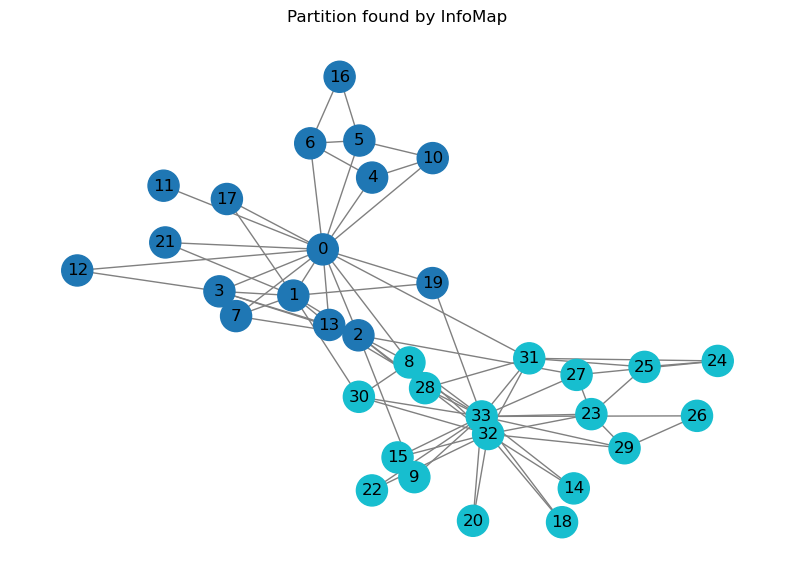

L of the found partition: 4.5466 bits


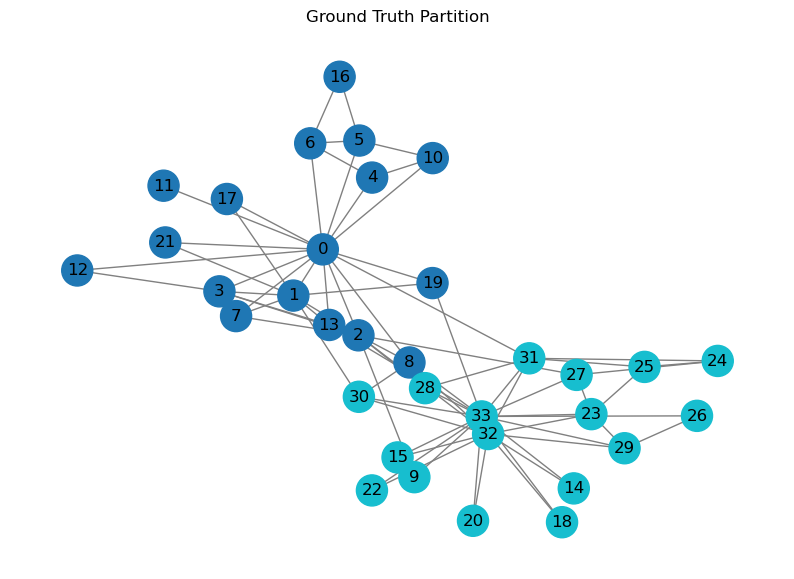

"Correct" L : 4.5885 bits


In [57]:
# Get the graph
G = nx.karate_club_graph()
final_partition = infoMapLouvain(G)
draw_partition(G, final_partition, title="Partition found by InfoMap")
# Now compute the final L for the found partition
L = mapEquation(G, final_partition, nx.pagerank(G, alpha=0.85))
print(f"L of the found partition: {L:.4f} bits")

ground_truth = {}
for n in G.nodes(data=True):
    ground_truth[n[0]] = 0 if n[1]['club'] == 'Mr. Hi' else 1
draw_partition(G, ground_truth, title="Ground Truth Partition")
    
L_gt = mapEquation(G, ground_truth, nx.pagerank(G, alpha=0.85))
print(f"\"Correct\" L : {L_gt:.4f} bits")

Now let's use the actual optimized version of InfoMap:

L (Codelength): 4.3118 bits
Moduli trovati: 3


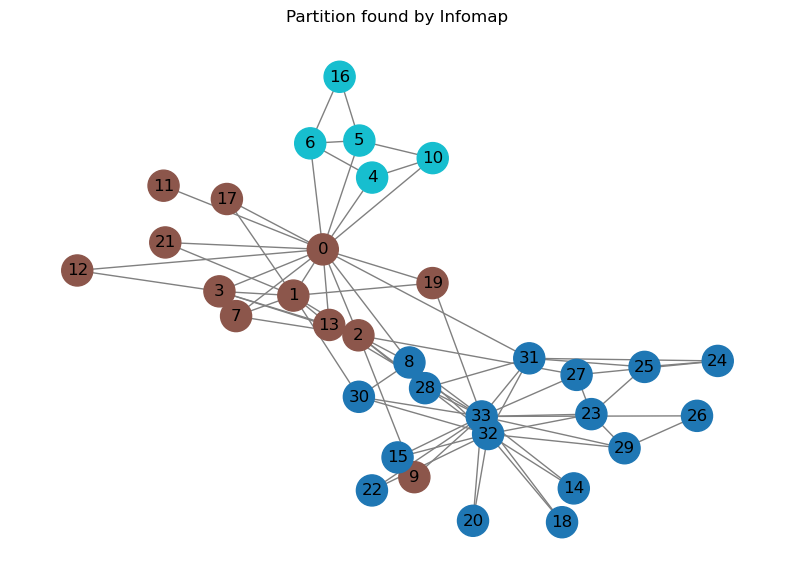

In [67]:
G = nx.karate_club_graph()

im = Infomap("--silent") 
im.add_links(G.edges())
im.run()

print(f"L (Codelength): {im.codelength:.4f} bits")
print(f"Moduli trovati: {im.num_top_modules}")

partition_infomap = {}
for node in im.nodes:
    partition_infomap[node.node_id] = node.module_id

draw_partition(G, partition_infomap, title="Partition found by Infomap")